# 05 — Champion Improvements (Multi-Horizon): Jump-Gated ARIMAX→CatBoost + 5 upgrade directions

Champion = **ARIMAX** (nb04) + **CatBoost** learns the residual + **Jump Gate** → **Jump-Gated ARIMAX-CatBoost (BASE)**.
Test **5 directions**: (1) **LSH**, (2) **SAX + date→text + LTH hashing**, (3) **TDA (Star+Sequence)**, (4) **B-spline (auto)**, (5) **Ensemble (NNLS stack)**.

Run on **multiple horizons**: **H = 1, 5, 10, 30, 60**. Any model that does not support a horizon is skipped. Metrics: MAE/MAPE/SMAPE/R2.
No file saving (display inline only).

--- ARIMAX residual = H-step rolling (fit on first 50%, extend forecast H steps). TDA/hashing/B-spline features are computed **once** (independent of H). ---

In [12]:
import warnings; warnings.filterwarnings("ignore")
import sys
from pathlib import Path
import numpy as np, pandas as pd
ROOT = Path.cwd();  ROOT = ROOT.parent if ROOT.name == "notebooks" else ROOT
sys.path.insert(0, str(ROOT))

CONFIG = {
    "target":   "MG95",
    "horizons": [1, 5, 10, 30, 60],
    "exog":     ["WTI", "USD_Index", "GPR", "BRT DTD", "Brent_EU_Daily"],
    "cb_iters": 250,
    "cb_depth": 6,
    "win":      24,
    "fit_ratio":0.5,      # phan dau de fit ARIMAX, phan con lai roll H-step
    "seed":     42,
}
print("CONFIG =", CONFIG)

CONFIG = {'target': 'MG95', 'horizons': [1, 5, 10, 30, 60], 'exog': ['WTI', 'USD_Index', 'GPR', 'BRT DTD', 'Brent_EU_Daily'], 'cb_iters': 250, 'cb_depth': 6, 'win': 24, 'fit_ratio': 0.5, 'seed': 42}


## 1. Load + Sin/Cos(Date) + (optional) News

In [13]:
from src.data_loader import load_and_engineer
TARGET = CONFIG["target"]
df = load_and_engineer()
doy = df.index.dayofyear.values
df["DOY_sin"] = np.sin(2*np.pi*doy/365.25); df["DOY_cos"] = np.cos(2*np.pi*doy/365.25)
news_path = ROOT / "news-crawler" / "data" / "daily_features.csv"
if news_path.exists():
    nw = pd.read_csv(news_path, parse_dates=["date"]).set_index("date")
    nw = nw[~nw.index.duplicated(keep="last")].sort_index()
    df = df.join(nw, how="left"); df[list(nw.columns)] = df[list(nw.columns)].fillna(0.0)
    print("News joined:", len(nw.columns), "cot")
else:
    print("No news file -> skipped.")
feature_cols = [c for c in df.columns if c != TARGET]
y = df[TARGET].astype(float).values
exog = df[CONFIG["exog"]].astype(float).values
X = df[feature_cols].values
N = len(y); ntr = int(N*0.8); nval = int(N*0.9); n_fit = int(N*CONFIG["fit_ratio"])
print("df:", df.shape, "| features:", len(feature_cols), "| N:", N)

News joined: 16 cot
df: (4619, 70) | features: 69 | N: 4619


## 2. Metrics + Jump Gate + features computed once (TDA / SAX-hashing / B-spline)

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
def metrics(yt, yp, name, H):
    yt = np.asarray(yt, float); yp = np.asarray(yp, float)
    return {"Model": name, "Horizon": H, "MAE": round(mean_absolute_error(yt,yp),4),
            "RMSE": round(float(np.sqrt(mean_squared_error(yt,yp))),4),
            "MAPE(%)": round(float(np.mean(np.abs((yt-yp)/(np.abs(yt)+1e-8)))*100),4),
            "SMAPE(%)": round(float(np.mean(2*np.abs(yp-yt)/(np.abs(yt)+np.abs(yp)+1e-8))*100),4),
            "R2": round(float(r2_score(yt,yp)),4)}

# Jump Gate (based on recent volatility)
ret = np.diff(y, prepend=y[0])
vol = pd.Series(np.abs(ret)).rolling(10, min_periods=1).mean().values
gz = (vol - np.nanmedian(vol[:ntr])) / (np.nanstd(vol[:ntr]) + 1e-8)
GATE = 1.0/(1.0+np.exp(-gz))

# --- (3) TDA features (Star + Sequence) ---
from scipy.sparse.csgraph import minimum_spanning_tree
def sublevel_pers(w):
    n=len(w)
    if n<3: return (0,0.0,0.0)
    order=np.argsort(w,kind="mergesort"); parent=np.full(n,-1,int); rb={}; pers=[]
    def find(x):
        r=x
        while parent[r]>=0: r=parent[r]
        return r
    act=np.zeros(n,bool)
    for idx in order:
        act[idx]=True; rb[idx]=w[idx]
        for j in (idx-1,idx+1):
            if 0<=j<n and act[j]:
                ri,rj=find(idx),find(j)
                if ri!=rj:
                    bi,bj=rb[ri],rb[rj]
                    if bi<=bj: pers.append(w[idx]-bj); parent[rj]=ri; rb[ri]=bi
                    else: pers.append(w[idx]-bi); parent[ri]=rj; rb[rj]=bj
    pers=np.array([p for p in pers if p>1e-9])
    if len(pers)==0: return (0,0.0,0.0)
    pp=pers/pers.sum(); return (len(pers),float(pers.max()),float(-(pp*np.log(pp+1e-12)).sum()))
def takens_star(w,dim=3,delay=2,cap=14):
    n=len(w)-(dim-1)*delay
    if n<3: return (0.0,0.0,0.0)
    emb=np.column_stack([w[k*delay:k*delay+n] for k in range(dim)])
    if len(emb)>cap: emb=emb[np.linspace(0,len(emb)-1,cap).astype(int)]
    c=emb.mean(0); r=np.linalg.norm(emb-c,axis=1)
    D=np.sqrt(((emb[:,None,:]-emb[None,:,:])**2).sum(-1))
    e=minimum_spanning_tree(D).toarray(); e=e[e>0]
    return (float(r.std()),float(e.sum()),float(e.max() if e.size else 0.0))
W=CONFIG["win"]
TDA=np.array([[*sublevel_pers(y[max(0,i-W):i+1]), *takens_star(y[max(0,i-W):i+1])] for i in range(N)])

# --- (2) SAX + date->text + LTH hashing ---
from sklearn.feature_extraction.text import HashingVectorizer
import scipy.stats as st
def sax(series,w=8,a=5):
    s=(series-series.mean())/(series.std()+1e-8)
    paa=[s[int(i*len(s)/w):int((i+1)*len(s)/w)].mean() for i in range(w)]
    bp=st.norm.ppf(np.linspace(0,1,a+1)[1:-1]); letters="abcde"
    return "".join(letters[int(np.searchsorted(bp,v))] for v in paa)
texts=[]
for i in range(N):
    win=y[max(0,i-W):i+1]; sx=sax(win) if len(win)>=4 else "na"; d=df.index[i]
    lth="".join(str(int(abs(v)*7)%10) for v in np.log1p(win[-6:]))
    texts.append(f"y{d.year} m{d.month} w{d.weekday()} q{d.quarter} doy{d.dayofyear} sax_{sx} L{lth}")
HASH=HashingVectorizer(n_features=64, alternate_sign=False, token_pattern=r"[^ ]+").transform(texts).toarray()

# --- (4) B-spline (auto quantile knots) ---
from scipy.interpolate import BSpline
def bspline_basis(x,n_basis=8,degree=3):
    x=np.asarray(x,float); lo,hi=np.nanmin(x),np.nanmax(x)
    inner=np.quantile(x[~np.isnan(x)],np.linspace(0,1,max(2,n_basis-degree+1))); inner[0],inner[-1]=lo,hi
    t=np.r_[[lo]*degree, inner, [hi]*degree]
    try: return BSpline.design_matrix(np.clip(x,lo,hi),t,degree,extrapolate=True).toarray()
    except Exception: return np.zeros((len(x),n_basis))
BSPL=np.column_stack([bspline_basis(np.linspace(0,1,N)), bspline_basis(exog[:,0])])
print("Precomputed: TDA", TDA.shape, "| HASH", HASH.shape, "| BSPL", BSPL.shape)

Precomputed: TDA (4619, 6) | HASH (4619, 64) | BSPL (4619, 16)


## 3. Per-horizon context (H-step ARIMAX rolling) + residual predictors

In [15]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from catboost import CatBoostRegressor
from sklearn.preprocessing import StandardScaler
from collections import defaultdict
from scipy.optimize import nnls

def build_context(H):
    res = SARIMAX(y[:n_fit], exog=exog[:n_fit], order=(2,1,2),
                  enforce_stationarity=False, enforce_invertibility=False).fit(disp=False, maxiter=60)
    ar = np.full(N, np.nan); cur = res
    for o in range(n_fit-1, N-H):
        ar[o+H] = float(np.asarray(cur.forecast(steps=H, exog=exog[o+1:o+1+H]))[-1])
        cur = cur.extend(y[o+1:o+2], exog=exog[o+1:o+2])
    resid = y - ar
    og = np.arange(n_fit-1, N-H)
    tr = og[(og+H) < ntr]; va = og[((og+H) >= ntr) & ((og+H) < nval)]; te = og[(og+H) >= nval]
    return dict(H=H, ar=ar, resid=resid, tr=tr, va=va, te=te,
                y_te=y[te+H], ar_te=ar[te+H], g_te=GATE[te],
                y_va=y[va+H], ar_va=ar[va+H], g_va=GATE[va],
                rtr=resid[tr+H], rva=resid[va+H])

def cb_resid(ctx, extra=None):
    Xm = X if extra is None else np.column_stack([X, extra])
    m = CatBoostRegressor(iterations=CONFIG["cb_iters"], depth=CONFIG["cb_depth"],
                          learning_rate=0.04, loss_function="MAE", random_seed=CONFIG["seed"], verbose=0, thread_count=2)
    m.fit(Xm[ctx["tr"]], ctx["rtr"])
    return m.predict(Xm[ctx["va"]]), m.predict(Xm[ctx["te"]])

def lsh_resid(ctx, n_bits=18, n_tables=6):
    sc = StandardScaler().fit(X[ctx["tr"]]); Xs = sc.transform(X)
    rng = np.random.RandomState(CONFIG["seed"]); gmean = ctx["rtr"].mean()
    pv = np.zeros(len(ctx["va"])); pt = np.zeros(len(ctx["te"])); cv = np.zeros(len(ctx["va"])); ct = np.zeros(len(ctx["te"]))
    for _ in range(n_tables):
        P = rng.randn(Xs.shape[1], n_bits); code = (Xs@P>0).astype(np.int64).dot(1<<np.arange(n_bits))
        buck = defaultdict(list)
        for k,o in enumerate(ctx["tr"]): buck[code[o]].append(ctx["rtr"][k])
        bm = {kk: np.mean(v) for kk,v in buck.items()}
        for j,o in enumerate(ctx["va"]):
            if code[o] in bm: pv[j]+=bm[code[o]]; cv[j]+=1
        for j,o in enumerate(ctx["te"]):
            if code[o] in bm: pt[j]+=bm[code[o]]; ct[j]+=1
    rv = np.where(cv>0, pv/np.maximum(cv,1), gmean); rt = np.where(ct>0, pt/np.maximum(ct,1), gmean)
    return rv, rt
print("Context + residual models ready.")

Context + residual models ready.


## 4. Driver — run every model on every horizon

In [16]:
import time
results = []
for H in CONFIG["horizons"]:
    t0 = time.time(); print("="*60); print("HORIZON H =", H); print("="*60)
    ctx = build_context(H)
    y_te, ar_te, g_te = ctx["y_te"], ctx["ar_te"], ctx["g_te"]
    P = {}
    def add(name, rv, rt):
        P[name] = (np.asarray(rv), np.asarray(rt))
        results.append(metrics(y_te, ar_te + g_te*np.asarray(rt), name, H)); print(" ", results[-1])

    add("ARIMAX (champion)", np.zeros(len(ctx["va"])), np.zeros(len(ctx["te"])))
    add("Jump-Gated ARIMAX-CatBoost (BASE)", *cb_resid(ctx))
    add("(1) LSH analog", *lsh_resid(ctx))
    add("(2) SAX/date-text/LTH hashing", *cb_resid(ctx, HASH))
    add("(3) TDA (Star+Sequence)", *cb_resid(ctx, TDA))
    add("(4) B-spline (auto)", *cb_resid(ctx, BSPL))
    # (5) ensemble: NNLS stack on validation
    nm = [n for n in P if n != "ARIMAX (champion)"]
    Mv = np.column_stack([P[n][0] for n in nm]); Mt = np.column_stack([P[n][1] for n in nm])
    w_,_ = nnls(Mv, ctx["rva"]); w_ = w_/w_.sum() if w_.sum() > 0 else np.ones(len(nm))/len(nm)
    results.append(metrics(y_te, ar_te + g_te*(Mt@w_), "(5) ENSEMBLE (stack)", H)); print(" ", results[-1])
    print(f"  [H={H}] {time.time()-t0:.1f}s")
print("\nDONE. rows:", len(results))

HORIZON H = 1
  {'Model': 'ARIMAX (champion)', 'Horizon': 1, 'MAE': 1.4645, 'RMSE': 2.9157, 'MAPE(%)': 1.4944, 'SMAPE(%)': 1.4931, 'R2': 0.9734}
  {'Model': 'Jump-Gated ARIMAX-CatBoost (BASE)', 'Horizon': 1, 'MAE': 1.4356, 'RMSE': 2.8445, 'MAPE(%)': 1.4642, 'SMAPE(%)': 1.4672, 'R2': 0.9746}
  {'Model': '(1) LSH analog', 'Horizon': 1, 'MAE': 1.5136, 'RMSE': 2.9925, 'MAPE(%)': 1.5443, 'SMAPE(%)': 1.5417, 'R2': 0.9719}
  {'Model': '(2) SAX/date-text/LTH hashing', 'Horizon': 1, 'MAE': 1.4366, 'RMSE': 2.8197, 'MAPE(%)': 1.4628, 'SMAPE(%)': 1.464, 'R2': 0.9751}
  {'Model': '(3) TDA (Star+Sequence)', 'Horizon': 1, 'MAE': 1.4382, 'RMSE': 2.8808, 'MAPE(%)': 1.4631, 'SMAPE(%)': 1.4631, 'R2': 0.974}
  {'Model': '(4) B-spline (auto)', 'Horizon': 1, 'MAE': 1.4472, 'RMSE': 2.8837, 'MAPE(%)': 1.4731, 'SMAPE(%)': 1.4754, 'R2': 0.9739}
  {'Model': '(5) ENSEMBLE (stack)', 'Horizon': 1, 'MAE': 1.4339, 'RMSE': 2.8559, 'MAPE(%)': 1.4617, 'SMAPE(%)': 1.4637, 'R2': 0.9744}
  [H=1] 14.1s
HORIZON H = 5
  {'Mod

## 5. Results (display, not saved)

In [17]:
res_df = pd.DataFrame(results)
print("=== Full (long) ==="); display(res_df)
for met in ["MAE", "R2", "SMAPE(%)"]:
    print("---", met, "(Model x Horizon) ---")
    display(res_df.pivot_table(index="Model", columns="Horizon", values=met))

=== Full (long) ===


,Model,Horizon,MAE,RMSE,MAPE(%),SMAPE(%),R2
0,ARIMAX (champion),1,1.4645,2.9157,1.4944,1.4931,0.9734
1,Jump-Gated ARIMAX-CatBoost (BASE),1,1.4356,2.8445,1.4642,1.4672,0.9746
2,(1) LSH analog,1,1.5136,2.9925,1.5443,1.5417,0.9719
3,(2) SAX/date-text/LTH hashing,1,1.4366,2.8197,1.4628,1.4640,0.9751
4,(3) TDA (Star+Sequence),1,1.4382,2.8808,1.4631,1.4631,0.9740
5,(4) B-spline (auto),1,1.4472,2.8837,1.4731,1.4754,0.9739
6,(5) ENSEMBLE (stack),1,1.4339,2.8559,1.4617,1.4637,0.9744
7,ARIMAX (champion),5,2.9210,5.6527,2.9207,2.9419,0.8999
8,Jump-Gated ARIMAX-CatBoost (BASE),5,2.9152,5.5952,2.9135,2.9575,0.9019
9,(1) LSH analog,5,3.1585,6.0991,3.1395,3.1556,0.8834


--- MAE (Model x Horizon) ---


Horizon,1,5,10,30,60
Model,,,,,
(1) LSH analog,1.5136,3.1585,4.1469,6.8066,7.4271
(2) SAX/date-text/LTH hashing,1.4366,2.9367,3.8927,6.4010,7.1390
(3) TDA (Star+Sequence),1.4382,2.9734,3.9828,6.2814,7.0339
(4) B-spline (auto),1.4472,3.0099,3.8194,6.0283,6.6539
(5) ENSEMBLE (stack),1.4339,2.9367,3.8932,6.3095,7.0002
ARIMAX (champion),1.4645,2.9210,3.9488,6.2854,6.8976
Jump-Gated ARIMAX-CatBoost (BASE),1.4356,2.9152,3.8335,6.3489,7.0584


--- R2 (Model x Horizon) ---


Horizon,1,5,10,30,60
Model,,,,,
(1) LSH analog,0.9719,0.8834,0.7761,0.4450,0.4577
(2) SAX/date-text/LTH hashing,0.9751,0.8996,0.7922,0.4853,0.4389
(3) TDA (Star+Sequence),0.9740,0.8967,0.7850,0.4915,0.4355
(4) B-spline (auto),0.9739,0.8976,0.8016,0.5184,0.4853
(5) ENSEMBLE (stack),0.9744,0.8996,0.7914,0.4890,0.4442
ARIMAX (champion),0.9734,0.8999,0.7912,0.4974,0.4803
Jump-Gated ARIMAX-CatBoost (BASE),0.9746,0.9019,0.7929,0.4851,0.4323


--- SMAPE(%) (Model x Horizon) ---


Horizon,1,5,10,30,60
Model,,,,,
(1) LSH analog,1.5417,3.1556,4.1539,6.7991,7.6337
(2) SAX/date-text/LTH hashing,1.4640,2.9662,3.9384,6.3792,7.2193
(3) TDA (Star+Sequence),1.4631,2.9997,4.0275,6.2466,7.1011
(4) B-spline (auto),1.4754,3.0643,3.9096,6.0178,6.7104
(5) ENSEMBLE (stack),1.4637,2.9662,3.9338,6.2711,7.0658
ARIMAX (champion),1.4931,2.9419,3.9619,6.2715,6.9792
Jump-Gated ARIMAX-CatBoost (BASE),1.4672,2.9575,3.8893,6.3209,7.1541


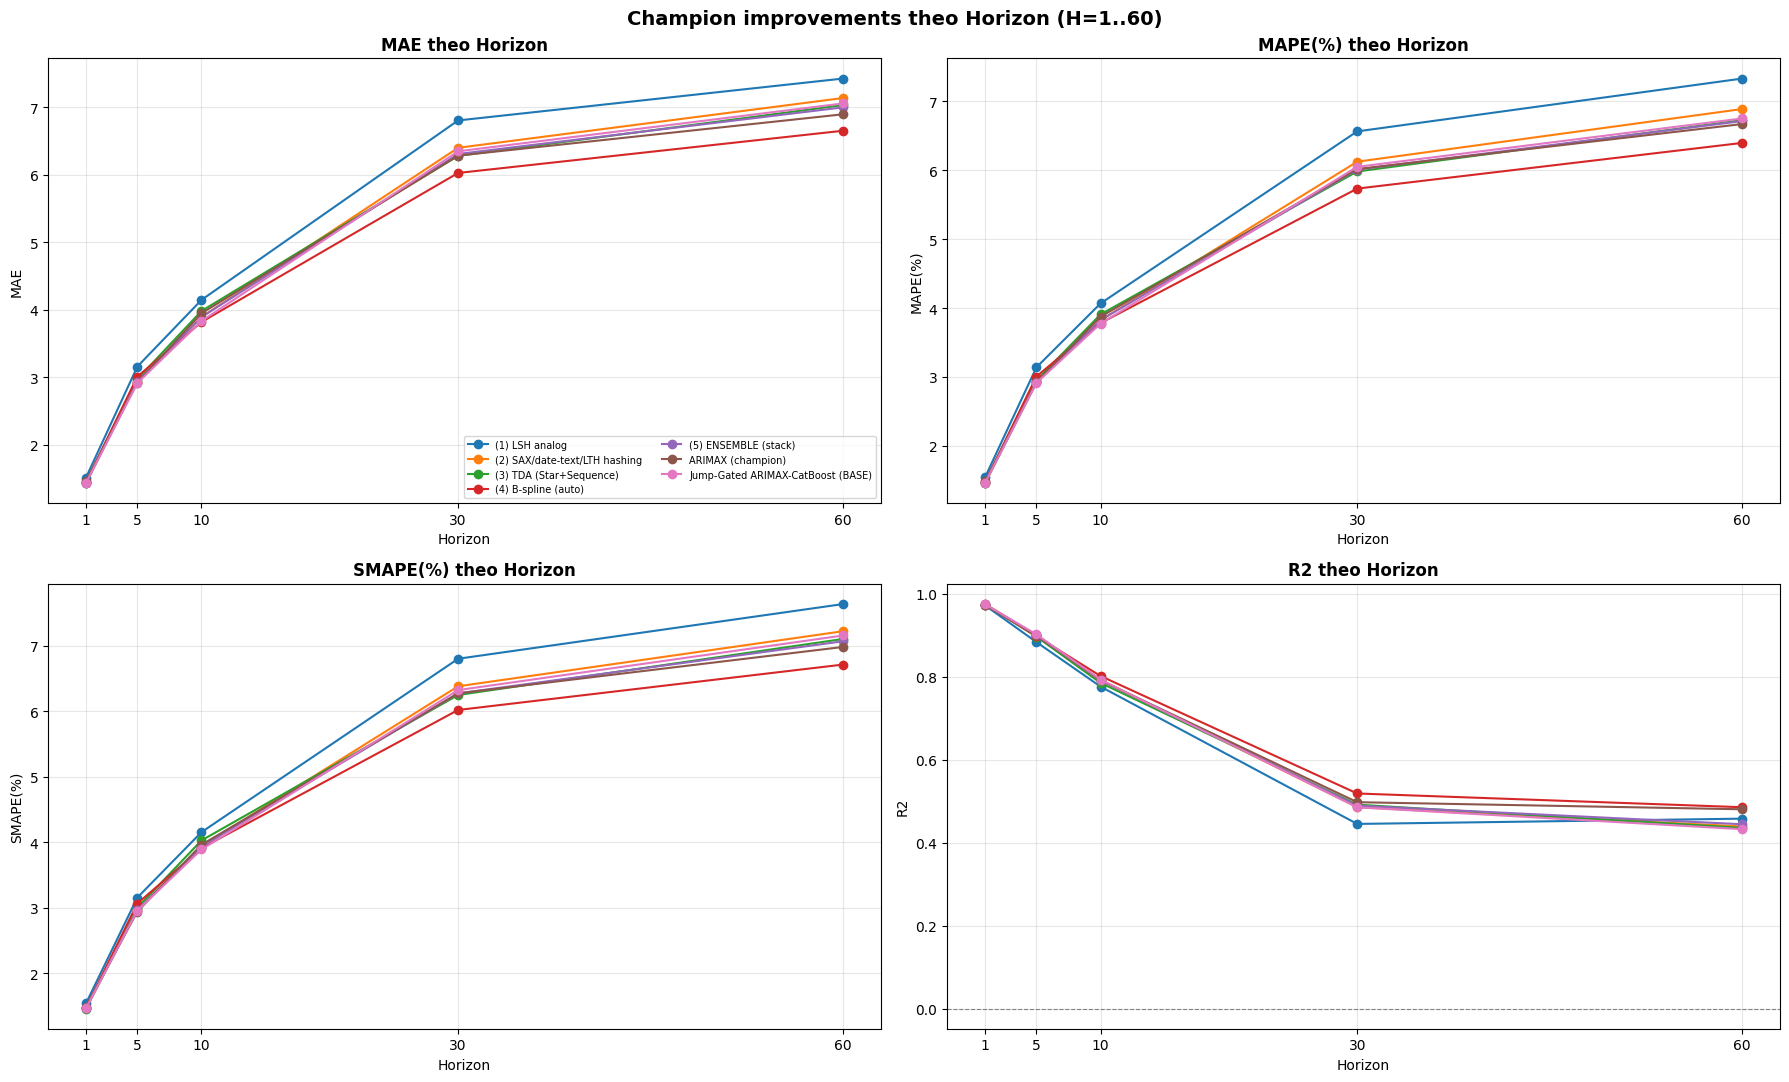

Best (thap MAE nhat) moi horizon:
  H=1 : (5) ENSEMBLE (stack)                   MAE=1.434 R2=0.974
  H=5 : Jump-Gated ARIMAX-CatBoost (BASE)      MAE=2.915 R2=0.902
  H=10: (4) B-spline (auto)                    MAE=3.819 R2=0.802
  H=30: (4) B-spline (auto)                    MAE=6.028 R2=0.518
  H=60: (4) B-spline (auto)                    MAE=6.654 R2=0.485


In [18]:
import matplotlib.pyplot as plt
mets = ["MAE", "MAPE(%)", "SMAPE(%)", "R2"]
fig, axes = plt.subplots(2, 2, figsize=(18, 11))
for ax, met in zip(axes.ravel(), mets):
    piv = res_df.pivot_table(index="Horizon", columns="Model", values=met)
    for col in piv.columns:
        ax.plot(piv.index, piv[col], marker="o", lw=1.5, label=col)
    ax.set_title(met + " by Horizon", fontweight="bold")
    ax.set_xlabel("Horizon"); ax.set_ylabel(met); ax.set_xticks(CONFIG["horizons"]); ax.grid(alpha=0.3)
    if met == "R2": ax.axhline(0, color="grey", lw=0.8, ls="--")
axes.ravel()[0].legend(fontsize=7, ncol=2)
plt.suptitle("Champion improvements by Horizon (H=1..60)", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

# best model per horizon
print("Best (thap MAE nhat) moi horizon:")
for H in CONFIG["horizons"]:
    sub = res_df[res_df.Horizon == H].sort_values("MAE").iloc[0]
    print(f"  H={H:<2d}: {sub['Model']:38s} MAE={sub['MAE']:.3f} R2={sub['R2']:.3f}")